In [1]:
# 必要なライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 日本語表示の設定（グラフ用）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 表示設定
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

print("✅ ライブラリのインポート完了")
print(f"pandas version: {pd.__version__}")
print(f"seaborn version: {sns.__version__}")

✅ ライブラリのインポート完了
pandas version: 2.2.3
seaborn version: 0.13.2


In [2]:
# seabornからタイタニックデータを読み込み
titanic = sns.load_dataset('titanic')

print("🚢 タイタニックデータを読み込みました")
print(f"データの形状: {titanic.shape}")
print(f"行数: {titanic.shape[0]} 件")
print(f"列数: {titanic.shape[1]} 列")

🚢 タイタニックデータを読み込みました
データの形状: (891, 15)
行数: 891 件
列数: 15 列


In [3]:
# データの最初の5行を表示
print("📋 データの最初の5行:")
titanic.head()

📋 データの最初の5行:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# データの基本情報を確認
# 各列のデータ型と欠損値の数がわかる
print("📋 データの基本情報:")
print("=" * 50)
titanic.info()

📋 データの基本情報:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
# 数値データの統計情報
# 平均・最大・最小・標準偏差などが確認できる
print("📊 数値データの統計情報:")
titanic.describe()

📊 数値データの統計情報:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# 欠損値（NaN）の数を確認
# 機械学習では欠損値の処理が非常に重要
print("❓ 各列の欠損値の数:")
print("=" * 50)
missing = titanic.isnull().sum()
missing_percent = (titanic.isnull().sum() / len(titanic) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent(%)': missing_percent
})

# 欠損値がある列だけ表示
print(missing_df[missing_df['missing_count'] > 0])
print(f"\n全体の行数: {len(titanic)} 件")

❓ 各列の欠損値の数:
             missing_count  missing_percent(%)
age                    177                19.9
embarked                 2                 0.2
deck                   688                77.2
embark_town              2                 0.2

全体の行数: 891 件


In [7]:
# タイタニックデータの各列の意味
print("📖 各列の説明:")
print("=" * 50)
columns_info = {
    'survived':    '生存（0=死亡, 1=生存）← これが予測ターゲット',
    'pclass':      'チケットクラス（1=上流, 2=中流, 3=下流）',
    'sex':         '性別（male=男性, female=女性）',
    'age':         '年齢',
    'sibsp':       '同乗した兄弟/配偶者の数',
    'parch':       '同乗した親/子供の数',
    'fare':        '運賃',
    'embarked':    '乗船した港（C/Q/S）',
    'class':       'チケットクラス（文字列版）',
    'who':         '男性/女性/子供',
    'adult_male':  '成人男性かどうか',
    'deck':        '船のデッキ',
    'embark_town': '乗船した港（都市名）',
    'alive':       '生存（yes/no）',
    'alone':       '一人で乗船したか'
}

for col, desc in columns_info.items():
    print(f"  {col:15s}: {desc}")

📖 各列の説明:
  survived       : 生存（0=死亡, 1=生存）← これが予測ターゲット
  pclass         : チケットクラス（1=上流, 2=中流, 3=下流）
  sex            : 性別（male=男性, female=女性）
  age            : 年齢
  sibsp          : 同乗した兄弟/配偶者の数
  parch          : 同乗した親/子供の数
  fare           : 運賃
  embarked       : 乗船した港（C/Q/S）
  class          : チケットクラス（文字列版）
  who            : 男性/女性/子供
  adult_male     : 成人男性かどうか
  deck           : 船のデッキ
  embark_town    : 乗船した港（都市名）
  alive          : 生存（yes/no）
  alone          : 一人で乗船したか


In [8]:
# 全体の生存率を確認
survived_counts = titanic['survived'].value_counts()
survived_percent = titanic['survived'].mean() * 100

print(f"🚢 全体の生存率: {survived_percent:.1f}%")
print(f"  生存: {survived_counts[1]} 人")
print(f"  死亡: {survived_counts[0]} 人")
print(f"  合計: {len(titanic)} 人")

🚢 全体の生存率: 38.4%
  生存: 342 人
  死亡: 549 人
  合計: 891 人


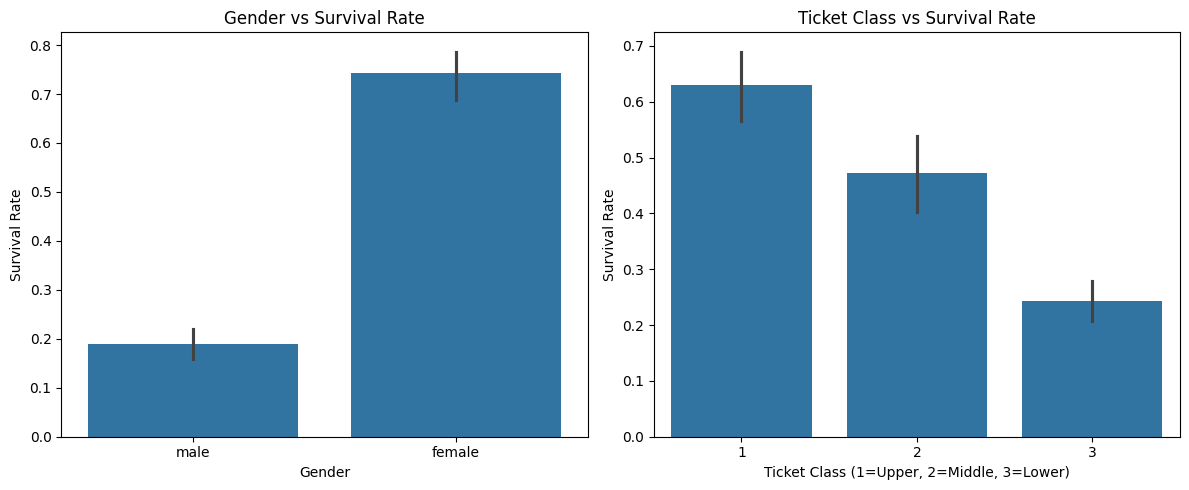

✅ グラフを outputs/ フォルダに保存しました


In [9]:
# 性別とクラス別の生存率をグラフで確認
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左：性別ごとの生存率
sns.barplot(x='sex', y='survived', data=titanic, ax=axes[0])
axes[0].set_title('Gender vs Survival Rate')
axes[0].set_ylabel('Survival Rate')
axes[0].set_xlabel('Gender')

# 右：チケットクラスごとの生存率
sns.barplot(x='pclass', y='survived', data=titanic, ax=axes[1])
axes[1].set_title('Ticket Class vs Survival Rate')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xlabel('Ticket Class (1=Upper, 2=Middle, 3=Lower)')

plt.tight_layout()
plt.savefig('../outputs/survival_by_gender_class.png')
plt.show()

print("✅ グラフを outputs/ フォルダに保存しました")

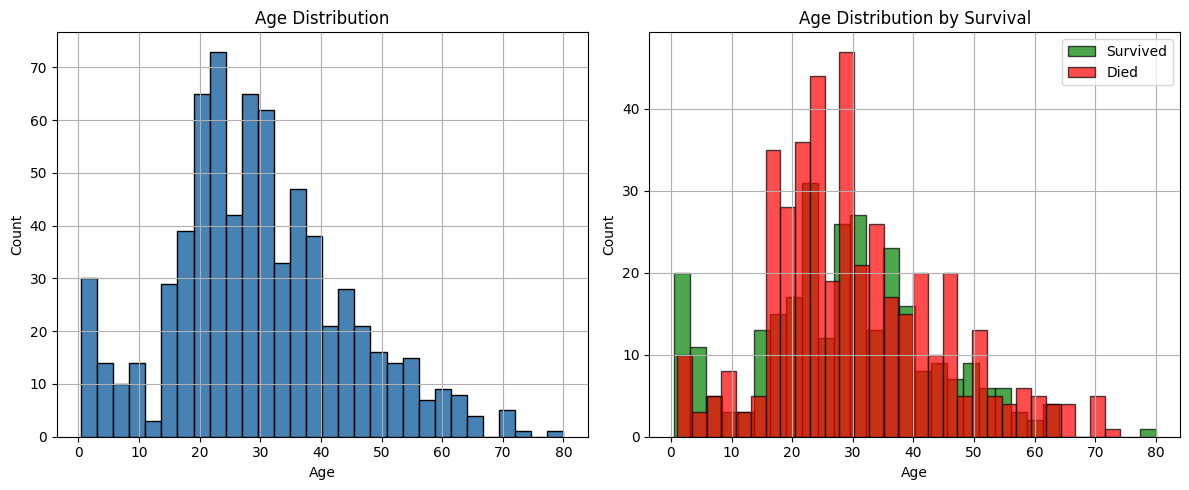

✅ グラフを outputs/ フォルダに保存しました


In [10]:
# 年齢の分布を確認
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左：年齢の分布（全体）
titanic['age'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# 右：生存/死亡別の年齢分布
titanic[titanic['survived']==1]['age'].hist(
    bins=30, ax=axes[1], alpha=0.7, label='Survived', color='green', edgecolor='black'
)
titanic[titanic['survived']==0]['age'].hist(
    bins=30, ax=axes[1], alpha=0.7, label='Died', color='red', edgecolor='black'
)
axes[1].set_title('Age Distribution by Survival')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/age_distribution.png')
plt.show()

print("✅ グラフを outputs/ フォルダに保存しました")